# SEMBRA — Surrogate for Elastomer Membrane Behavior under Radial loading and Actuation

### Voltage-Controlled

This tool predicts the equilibrium state of a voltage-controlled dielectric
elastomer membrane and identifies its electromechanical instability behavior under
combined mechanical and electrical loading. From three nondimensional inputs
— the Ogden hyperelastic exponent `alpha`, the electrical-loading parameter
`alpha_p`, and the inflation pressure `p` — the tool predicts the membrane
equilibrium state and reports diagnostics for the principal failure modes:
electromechanical instability, wrinkling, electrical breakdown, and rupture.

In [1]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import math
import sys
import warnings
from pathlib import Path

# DEC-014: discover the SEMBRA project root by walking up from the notebook's cwd.
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / 'sembra' / '__init__.py').exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise RuntimeError(
        'Could not locate the SEMBRA project root (no sembra/__init__.py found in any ancestor).'
    )

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    import io
    import base64
    from IPython.display import HTML, display
    from sembra import PROJECT_ROOT, LOGS_DIR
    from sembra.utils import compute_stress, detect_wrinkling, compute_max_electric_field
    from sembra.wrapper import predict
    from sembra.envelope import load_envelope_models, predict_p_crit
    from sembra.data import load_full_dataset, split_stable_unstable
    _ = predict(1.6, 0.10, 0.5)  # warm up cached resources silently


## Usage

Edit `alpha` (recommended range [1.2, 2.0]), `alpha_p` (recommended range [0, 0.4]), and `p` in the cell below and run it. The output
includes the equilibrium state, diagnostics for the principal failure modes,
and two figures: the principal Cauchy stresses on the deformed dome, and the
location of the query in the (α_p, p) plane at the chosen `alpha`.

Plots are saved to `logs/plots/user_queries/` and overwritten on each re-run.

                 Sembra — Voltage-Controlled                  

  Input
    alpha    = 1.5
    alpha_p  = 0.3
    p        = 0.4

  Equilibrium state
    lambda_0 = 1.283131
    eta_0    = 0.577296
    det_H    = +0.258032

  Failure modes
    Electromechanical instability:  NOT DETECTED ✓
      p_crit ≈ 0.6014,  pressure difference = 33.49%
    Wrinkling instability:      DETECTED ✗
      Triggered by σ_2 near r ≈ 0.89
    Peak electric field:        Ē_max = 1.6464
    Peak stresses
      σ_1_max = 0.1833 at r ≈ 1.00
      σ_2_max = 0.1669 at r ≈ 0.00

  Equilibrium residuals: |∂Π/∂λ_0| = 1.70e-04, |∂Π/∂η_0| = 2.09e-04



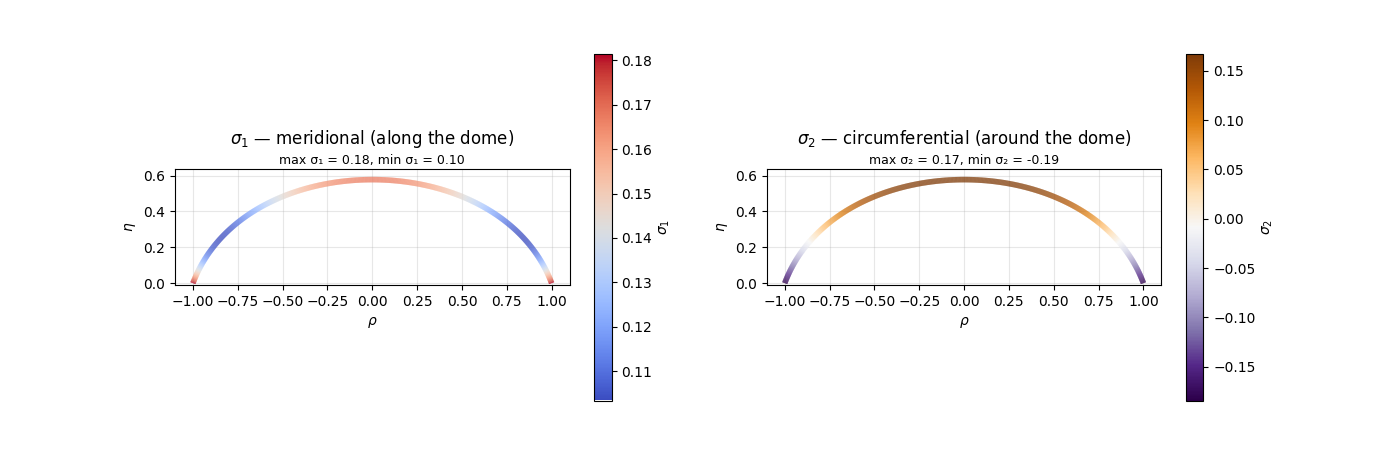


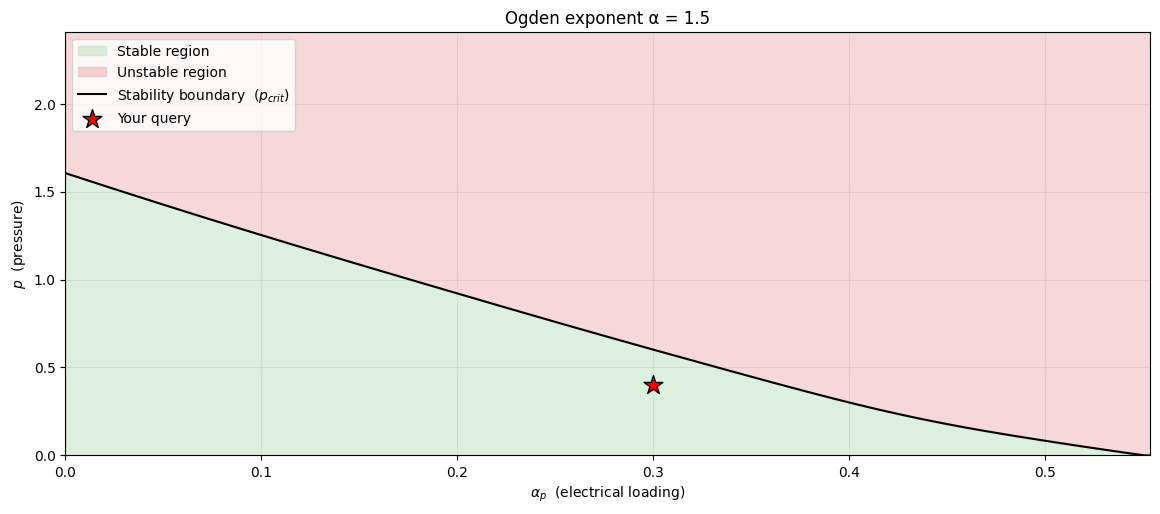

In [7]:
alpha = 1.5
alpha_p = 0.30
p = 0.40

# --- Prediction ---
with warnings.catch_warnings(), np.errstate(invalid='ignore', divide='ignore'):
    warnings.simplefilter('ignore')
    result = predict(alpha, alpha_p, p)

# --- Failure-mode scalars (available regardless of branch) ---
p_crit = float(result.diagnostics.get('p_crit', float('nan')))
margin_pct = abs((p - p_crit) / p_crit * 100.0) if p_crit > 0 else float('nan')
pull_in_verdict = 'NOT DETECTED \u2713' if result.stable else 'DETECTED \u2717'
res_l = abs(result.diagnostics.get('residual_dPi_dlambda_0', float('nan')))
res_e = abs(result.diagnostics.get('residual_dPi_deta_0', float('nan')))

# --- Geometry, stress, wrinkling (guarded for the no-stable-region branch) ---
_state_ok = not (math.isnan(result.lambda_0) or math.isnan(result.eta_0))
if _state_ok:
    with warnings.catch_warnings(), np.errstate(invalid='ignore', divide='ignore'):
        warnings.simplefilter('ignore')
        r_grid = np.linspace(0.0, 1.0, 401)
        lambda_2_grid = r_grid**2 + result.lambda_0 * (1.0 - r_grid**2)
        rho_grid = r_grid * lambda_2_grid
        eta_grid = result.eta_0 * (1.0 - r_grid**2)
        stress = compute_stress(alpha, alpha_p, p, r_grid)
        sigma_1 = stress['sigma_1']
        sigma_2 = stress['sigma_2']

    wrinkling = detect_wrinkling(stress)
    if wrinkling['detected']:
        wrinkling_verdict = 'DETECTED \u2717'
        parts = []
        if wrinkling['sigma_1_intervals']:
            r_mids = ', '.join(f'{interval[2]:.2f}' for interval in wrinkling['sigma_1_intervals'])
            parts.append(f'\u03c3_1 near r \u2248 {r_mids}')
        if wrinkling['sigma_2_intervals']:
            r_mids = ', '.join(f'{interval[2]:.2f}' for interval in wrinkling['sigma_2_intervals'])
            parts.append(f'\u03c3_2 near r \u2248 {r_mids}')
        wrinkling_detail = 'Triggered by ' + ' and '.join(parts)
    else:
        wrinkling_verdict = 'NOT DETECTED \u2713'
        wrinkling_detail = None

    s1_argmax = int(np.argmax(sigma_1))
    s2_argmax = int(np.argmax(sigma_2))
    s1_max = float(sigma_1[s1_argmax])
    s2_max = float(sigma_2[s2_argmax])
    s1_argmax_r = float(r_grid[s1_argmax])
    s2_argmax_r = float(r_grid[s2_argmax])

# --- Save destination (deterministic filenames overwritten on re-run) ---
plots_dir = LOGS_DIR / 'plots' / 'user_queries'
plots_dir.mkdir(parents=True, exist_ok=True)
stem = f'a{alpha}_ap{alpha_p}_p{p}'.replace('.', 'p')

# --- Text box (printed as four pieces to mitigate per-output truncation) ---
_bar = '=' * 62
_title_line = 'Sembra \u2014 Voltage-Controlled'.center(62)

_piece_a = (
    f'{_bar}\n'
    f'{_title_line}\n'
    f'{_bar}\n'
    f'\n'
    f'  Input\n'
    f'    alpha    = {alpha}\n'
    f'    alpha_p  = {alpha_p}\n'
    f'    p        = {p}\n'
    f'\n'
    f'  Equilibrium state\n'
    f'    lambda_0 = {result.lambda_0:.6f}\n'
    f'    eta_0    = {result.eta_0:.6f}\n'
    f'    det_H    = {result.det_H:+.6f}'
)
print(_piece_a)

# Peak electric field (VC: Ē_max = lambda_0^2 at the pole; section 4.4)
if math.isnan(result.lambda_0):
    peak_e_block = '    Peak electric field:        N/A'
else:
    peak_e_max = compute_max_electric_field(result.lambda_0)
    peak_e_block = f'    Peak electric field:        Ē_max = {peak_e_max:.4f}'

if _state_ok:
    if wrinkling['detected']:
        wrinkling_block = (
            f'    Wrinkling instability:      {wrinkling_verdict}\n'
            f'      {wrinkling_detail}'
        )
    else:
        wrinkling_block = f'    Wrinkling instability:      {wrinkling_verdict}'
    _piece_b = (
        f'\n'
        f'  Failure modes\n'
        f'    Electromechanical instability:  {pull_in_verdict}\n'
        f'      p_crit \u2248 {p_crit:.4f},  pressure difference = {margin_pct:.2f}%\n'
        f'{wrinkling_block}\n'
        f'{peak_e_block}\n'
        f'    Peak stresses\n'
        f'      \u03c3_1_max = {s1_max:.4f} at r \u2248 {s1_argmax_r:.2f}\n'
        f'      \u03c3_2_max = {s2_max:.4f} at r \u2248 {s2_argmax_r:.2f}'
    )
else:
    _piece_b = (
        f'\n'
        f'  Failure modes\n'
        f'    Electromechanical instability:  {pull_in_verdict}\n'
        f'      p_crit \u2248 {p_crit:.4f},  pressure difference = {margin_pct:.2f}%\n'
        f'    Wrinkling instability:      N/A (no stable region)\n'
        f'{peak_e_block}\n'
        f'    Peak stresses\n'
        f'      N/A'
    )
print(_piece_b)

if math.isnan(res_l) or math.isnan(res_e):
    _piece_b2 = '\n  Equilibrium residuals: not applicable for this branch'
else:
    _piece_b2 = (
        f'\n  Equilibrium residuals: '
        f'|\u2202\u03a0/\u2202\u03bb_0| = {res_l:.2e}, '
        f'|\u2202\u03a0/\u2202\u03b7_0| = {res_e:.2e}'
    )
print(_piece_b2)

_piece_c = f'\n{_bar}'
print(_piece_c)


def _draw_side_stress(ax, sigma_field, cmap='coolwarm'):
    pts_right = np.array([rho_grid, eta_grid]).T.reshape(-1, 1, 2)
    pts_left = np.array([-rho_grid, eta_grid]).T.reshape(-1, 1, 2)
    seg_right = np.concatenate([pts_right[:-1], pts_right[1:]], axis=1)
    seg_left = np.concatenate([pts_left[:-1], pts_left[1:]], axis=1)
    all_seg = np.concatenate([seg_right, seg_left])
    all_col = np.concatenate([sigma_field[:-1], sigma_field[:-1]])
    lc = LineCollection(all_seg, cmap=cmap, linewidth=4.0)
    lc.set_array(all_col)
    ax.add_collection(lc)
    ax.set_xlabel(r'$\rho$')
    ax.set_ylabel(r'$\eta$')
    ax.grid(True, alpha=0.3)
    return lc


if _state_ok:
    # --- Figure 1: sigma_1 and sigma_2 side-views, side by side ---
    fig_stress, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(14, 4.5))

    lc_s1 = _draw_side_stress(ax_s1, sigma_1, cmap='coolwarm')
    ax_s1.set_title(r'$\sigma_1$ — meridional (along the dome)', pad=18)
    fig_stress.colorbar(lc_s1, ax=ax_s1, label=r'$\sigma_1$')

    lc_s2 = _draw_side_stress(ax_s2, sigma_2, cmap='PuOr_r')
    ax_s2.set_title(r'$\sigma_2$ — circumferential (around the dome)', pad=18)
    fig_stress.colorbar(lc_s2, ax=ax_s2, label=r'$\sigma_2$')

    sub_s1 = f'max σ₁ = {sigma_1[s1_argmax]:.2f}, min σ₁ = {sigma_1[int(np.argmin(sigma_1))]:.2f}'
    sub_s2 = f'max σ₂ = {sigma_2[s2_argmax]:.2f}, min σ₂ = {sigma_2[int(np.argmin(sigma_2))]:.2f}'
    ax_s1.text(0.5, 1.02, sub_s1, transform=ax_s1.transAxes,
               ha='center', va='bottom', fontsize=9, color='black')
    ax_s2.text(0.5, 1.02, sub_s2, transform=ax_s2.transAxes,
               ha='center', va='bottom', fontsize=9, color='black')

    rho_max = float(np.abs(rho_grid).max())
    eta_max = float(eta_grid.max())
    x_pad = 0.10 * rho_max
    y_pad = 0.10 * eta_max
    for ax in (ax_s1, ax_s2):
        ax.set_xlim(-rho_max - x_pad, rho_max + x_pad)
        ax.set_ylim(0 - 0.02 * eta_max, eta_max + y_pad)
        ax.set_aspect('equal')

    fig_stress.savefig(plots_dir / f'stress_{stem}.png', dpi=150, bbox_inches='tight')
    display(fig_stress)
    plt.close(fig_stress)

    # --- Figure 2: design-space plot at user's alpha ---
    with warnings.catch_warnings(), np.errstate(invalid='ignore', divide='ignore'):
        warnings.simplefilter('ignore')
        _p_crit_model, _ = load_envelope_models()
        _ap_test = np.linspace(0.0, 0.72, 200)
        _p_crit_test = predict_p_crit(_p_crit_model,
                                      np.full_like(_ap_test, alpha),
                                      _ap_test)
        _zero_idx = np.where(_p_crit_test <= 0)[0]
        ap_max_envelope = _ap_test[_zero_idx[0]] if len(_zero_idx) > 0 else 0.72
        x_max = max(ap_max_envelope, alpha_p * 1.05)

        ap_grid = np.linspace(0.0, x_max, 200)
        p_crit_curve = predict_p_crit(_p_crit_model,
                                      np.full_like(ap_grid, alpha),
                                      ap_grid)
        p_crit_curve = np.maximum(p_crit_curve, 0.0)

    y_max = max(1.5 * np.max(p_crit_curve), p * 1.05)

    fig_ds, ax_ds = plt.subplots(figsize=(14, 5.5))
    ax_ds.fill_between(ap_grid, 0.0, p_crit_curve,
                       color='#9fd49f', alpha=0.35,
                       label='Stable region')
    ax_ds.fill_between(ap_grid, p_crit_curve, y_max,
                       color='#e89090', alpha=0.35,
                       label='Unstable region')
    ax_ds.plot(ap_grid, p_crit_curve,
               color='black', linewidth=1.5,
               label=r'Stability boundary  ($p_{crit}$)')
    ax_ds.scatter([alpha_p], [p],
                  marker='*', s=200,
                  color='red', edgecolors='black', linewidths=1.0,
                  zorder=10, label='Your query')
    ax_ds.set_xlim(0.0, x_max)
    ax_ds.set_ylim(0.0, y_max)
    ax_ds.set_title(f'Ogden exponent α = {alpha}')
    ax_ds.set_xlabel(r'$\alpha_p$  (electrical loading)')
    ax_ds.set_ylabel(r'$p$  (pressure)')
    ax_ds.legend(loc='upper right' if alpha_p <= x_max / 2 else 'upper left')
    ax_ds.grid(True, alpha=0.3)
    ax_ds.set_axisbelow(True)
    fig_ds.savefig(plots_dir / f'design_space_{stem}.png', dpi=150)

    _buf = io.BytesIO()
    fig_ds.savefig(_buf, format='png', dpi=100, bbox_inches='tight')
    _buf.seek(0)
    _img_b64 = base64.b64encode(_buf.read()).decode('ascii')
    _html = (
        '<div style="text-align: center; width: 100%;">'
        f'<img src="data:image/png;base64,{_img_b64}" '
        'style="max-width: 65%; height: auto; display: inline-block;" />'
        '</div>'
    )
    display(HTML(_html))
    plt.close(fig_ds)
else:
    print('\n(No stable region for these inputs — figures skipped.)')
